In [ ]:
class CSVAdapter():
    def _init_(self,csv_path):
        self.csv_path = csv_path
        self.dict = pd.read_csv(csv_path).to_dict(orient='records')
    def get_item(self):
        return GenericIterator(self.dict)

@dataclass
class MarketRecord:
    """Representa um registro de mercado mensal."""
    last_bizday: str
    PRIO3_PERC_RETURN: float
    PRIO3_LONG_FUNDS_PERC_CHANGE: float

@dataclass
class ObjectData:
    """Contém e gerencia uma coleção de registros de mercado."""
    data: List[MarketRecord] = field(default_factory=list)

    def add_data(self, value: MarketRecord) -> None:
        if not isinstance(value, MarketRecord):
            raise TypeError("value deve ser uma instância de MarketRecord")
        self.data.append(value)

    def get_item(self) -> GenericIterator:
        return GenericIterator(self.data)

    def describe(self) -> dict:
        if not self.data:
            return {"n_records": 0, "n_columns": 0}
        n_columns = len(self.data[0]._dataclass_fields_)
        return {"n_records": len(self.data), "n_columns": n_columns}


class APIAdapter():
    def _init_(self,json_path='prio3_funds_apicall.json'):
        with open(json_path,'r') as f:
            self.dict = json.load(f)
    def get_item(self):
        return GenericIterator(self.dict)

In [12]:
import torch

print("CUDA disponível? ", torch.cuda.is_available())
print("Quantas GPUs?    ", torch.cuda.device_count())
print("Nome da GPU:     ", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
print("Versão CUDA:     ", torch.version.cuda)
print("Backend cuDNN:   ", torch.backends.cudnn.version())


CUDA disponível?  True
Quantas GPUs?     1
Nome da GPU:      NVIDIA GeForce RTX 3060
Versão CUDA:      12.8
Backend cuDNN:    91002


In [34]:
import numpy as np
import pandas as pd

from pathlib import Path

from ml.embedding import Embedder
from ml.clustering import Clusterer
from papers_lab.io import Storage, PaperTransform
from papers_lab import PaperAnalysis
from eda import Visualizer

###

root = Path("papers")
store = Storage()

researches = store.load_dir(root, pattern="*.pkl", recursive=True)

len(researches)
tx = PaperTransform()
df = tx.transform(researches, normalize_keywords=True)

###

abstracts = df["abstract"].dropna()

emb = Embedder(model_name="sentence-transformers/all-MiniLM-L6-v2")
X = emb.encode(abstracts)
X.shape

2025-10-06 22:59:27,731 | ERROR | storage:iter_dir:line54 - Error loading papers/acm/acm_research_concept_code_static_uml_0.pkl: No module named 'webscraping'
Traceback (most recent call last):
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 52, in iter_dir
    yield self.load(p)
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 34, in load
    pkl = pickle.load(f)
ModuleNotFoundError: No module named 'webscraping'
2025-10-06 22:59:27,733 | ERROR | storage:iter_dir:line54 - Error loading papers/acm/acm_research_groups_uml_oo_0.pkl: No module named 'webscraping'
Traceback (most recent call last):
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 52, in iter_dir
    yield self.load(p)
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 34, in load
    pkl = pickle.load(f)
ModuleNotFoundError: No module named 'webscraping'
2025-10-06 22:59:27,736 | ERROR | storag

(23, 384)

In [14]:
root = Path("papers")
store = Storage()

researches = store.load_dir(root, pattern="*.pkl", recursive=True)

len(researches)
tx = PaperTransform()
df = tx.transform(researches, normalize_keywords=True)

2025-10-06 21:50:34,559 | ERROR | storage:iter_dir:line54 - Error loading papers/acm/acm_research_concept_code_static_uml_0.pkl: No module named 'webscraping'
Traceback (most recent call last):
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 52, in iter_dir
    yield self.load(p)
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 34, in load
    pkl = pickle.load(f)
ModuleNotFoundError: No module named 'webscraping'
2025-10-06 21:50:34,560 | ERROR | storage:iter_dir:line54 - Error loading papers/acm/acm_research_groups_uml_oo_0.pkl: No module named 'webscraping'
Traceback (most recent call last):
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 52, in iter_dir
    yield self.load(p)
  File "/home/kenai/projects/vscode/lisa-llm-reqs/papers_lab/io/storage.py", line 34, in load
    pkl = pickle.load(f)
ModuleNotFoundError: No module named 'webscraping'
2025-10-06 21:50:34,562 | ERROR | storag

In [26]:
abstracts = df["abstract"].dropna()

emb = Embedder(model_name="sentence-transformers/all-MiniLM-L6-v2")
X = emb.encode(abstracts)
X.shape

(23, 384)

In [28]:
keywords = df["keywords"].dropna()

emb = Embedder(model_name="sentence-transformers/all-MiniLM-L6-v2")
X = emb.encode(keywords)
X.shape

(23, 384)

In [30]:
X = np.asarray(X)

clu = Clusterer(method="kmeans", n_clusters=3, reducer="umap")  # PCA fallback automático
labels = clu.fit_predict(X)

print("Resumo:", clu.summary(labels))
print("Silhouette:", clu.silhouette(X, labels))
print("Exemplos por cluster:", clu.exemplars(X, labels, k=3))
# clu.plot_2d(X, labels, title="KMeans nos embeddings")

2025-10-06 22:57:23,853 | INFO | clustering:fit:line68 - Fitting KMeans with n_clusters=3.
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
2025-10-06 22:57:23,857 | INFO | clustering:fit_predict:line103 - Returning KMeans labels.


Resumo: {0: 23}
Silhouette: None
Exemplos por cluster: {0: [0, 1, 2]}


2025-10-06 22:57:53,210 | INFO | clustering:fit:line82 - Fitting HDBSCAN with min_cluster_size=2.
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-10-06 22:57:53,213 | INFO | clustering:fit_predict:line97 - Returning HDBSCAN labels.
2025-10-06 22:57:53,215 | INFO | clustering:reduce:line52 - Reducing dimensions with UMAP.
/home/kenai/projects/vscode/lisa-llm-reqs/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Resumo HDBSCAN: {-1: 23}
Silhouette HDBSCAN: None
Exemplos por cluster: {0: [0, 1, 2]}


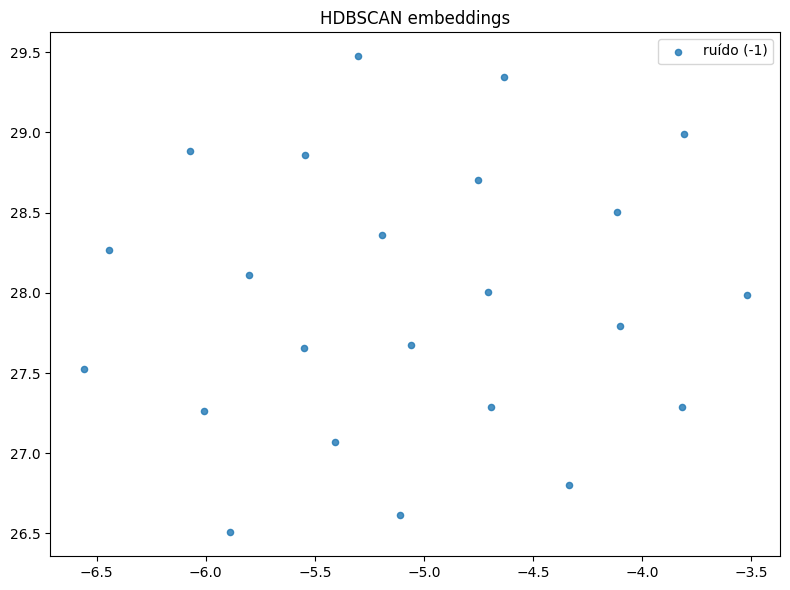

In [32]:
clu_h = Clusterer(method="hdbscan", min_cluster_size=2, reducer="umap")
labels_h = clu_h.fit_predict(X)
print("Resumo HDBSCAN:", clu_h.summary(labels_h))
print("Silhouette HDBSCAN:", clu_h.silhouette(X, labels_h))
print("Exemplos por cluster:", clu_h.exemplars(X, labels, k=3))
clu_h.plot_2d(X, labels_h, title="HDBSCAN embeddings")